In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df=pd.read_csv("greenxchange_dataset_20000.csv")

### EDA

In [3]:
df.head()

,AreaType,AQI,PM2.5,PM10,NO2,SO2,CO,O3,TrafficDensity,RoadDistance,...,Sunlight,SoilType,SoilPH,Drainage,SpaceType,AreaSize,MaintenanceLevel,WateringPreference,Purpose,RecommendedPlant
0,Residential,54,25.1,52.2,10.3,7.7,0.18,70.6,Medium,106,...,Full Shade,Loamy,6.1,Good,Indoor,Medium,Medium,Regular,Decoration,Aloe Vera
1,Urban,52,28.8,53.8,4.5,2.8,0.66,32.4,Low,83,...,Full Sun,Sandy,7.0,Moderate,Outdoor,Large,High,Regular,Edible,Ashoka
2,Residential,53,34.0,61.9,6.0,6.0,0.57,62.1,High,106,...,Full Shade,Loamy,7.9,Good,Indoor,Medium,High,Regular,Decoration,Peace Lily
3,Urban,67,15.7,33.9,3.8,5.5,0.36,78.2,Low,88,...,Partial Shade,Loamy,5.9,Good,Outdoor,Large,Medium,Regular,Edible,Ashoka
4,Residential,103,19.6,37.0,12.6,3.3,0.48,31.8,Low,93,...,Partial Shade,Loamy,7.7,Good,Indoor,Medium,Low,Frequent,Decoration,Peace Lily


In [4]:
df.tail()

,AreaType,AQI,PM2.5,PM10,NO2,SO2,CO,O3,TrafficDensity,RoadDistance,...,Sunlight,SoilType,SoilPH,Drainage,SpaceType,AreaSize,MaintenanceLevel,WateringPreference,Purpose,RecommendedPlant
19995,Residential,77,16.8,34.1,5.3,6.1,0.33,39.5,High,47,...,Partial Shade,Loamy,7.1,Good,Indoor,Medium,Medium,Regular,Shade,Peace Lily
19996,Urban,49,16.9,34.0,16.3,5.1,0.67,57.0,Low,36,...,Full Sun,Sandy,6.3,Poor,Indoor,Medium,High,Frequent,Air Purification,Areca Palm
19997,Residential,76,41.4,77.9,13.1,5.9,0.29,70.4,High,5,...,Partial Shade,Loamy,7.0,Poor,Outdoor,Large,Medium,Regular,Edible,Aloe Vera
19998,Rural,57,20.0,42.5,10.4,4.8,0.35,55.4,Medium,63,...,Full Shade,Loamy,7.9,Moderate,Outdoor,Large,Medium,Regular,Decoration,Coconut
19999,Urban,91,22.5,48.8,3.1,3.9,0.31,69.3,High,77,...,Partial Shade,Loamy,5.1,Good,Balcony,Small,Medium,Frequent,Decoration,Spider Plant


In [5]:
df.describe()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3,RoadDistance,DustIndex,Temperature,Humidity,Rainfall,WindSpeed,SoilPH
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,67.131850,25.919260,51.863710,10.500470,4.255535,0.449992,59.883965,77.034050,54.485650,27.982250,61.932200,222.973750,10.029050,6.597890
std,21.946023,9.857675,19.991404,5.486984,2.171812,0.202355,17.249053,42.069401,25.903813,7.754272,18.781023,100.897662,6.054861,0.926918
min,30.000000,8.800000,16.000000,1.000000,0.500000,0.100000,30.000000,5.000000,10.000000,15.000000,30.000000,50.000000,0.000000,5.000000
25%,48.000000,17.400000,34.600000,5.800000,2.400000,0.270000,44.900000,40.000000,32.000000,21.000000,46.000000,135.000000,5.000000,5.800000
50%,67.000000,25.800000,51.450000,10.500000,4.300000,0.450000,60.000000,77.000000,55.000000,28.000000,62.000000,223.000000,10.000000,6.600000
75%,86.000000,34.300000,68.600000,15.200000,6.100000,0.630000,74.800000,113.000000,77.000000,35.000000,78.000000,311.000000,15.000000,7.400000
max,105.000000,43.100000,94.500000,20.000000,8.000000,0.800000,90.000000,149.000000,99.000000,41.000000,94.000000,399.000000,20.000000,8.200000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AreaType            20000 non-null  str    
 1   AQI                 20000 non-null  int64  
 2   PM2.5               20000 non-null  float64
 3   PM10                20000 non-null  float64
 4   NO2                 20000 non-null  float64
 5   SO2                 20000 non-null  float64
 6   CO                  20000 non-null  float64
 7   O3                  20000 non-null  float64
 8   TrafficDensity      20000 non-null  str    
 9   RoadDistance        20000 non-null  int64  
 10  DustIndex           20000 non-null  int64  
 11  Temperature         20000 non-null  int64  
 12  Humidity            20000 non-null  int64  
 13  Rainfall            20000 non-null  int64  
 14  WindSpeed           20000 non-null  int64  
 15  Sunlight            20000 non-null  str    
 16  SoilType       

In [7]:
df.isnull().sum()

AreaType              0
AQI                   0
PM2.5                 0
PM10                  0
NO2                   0
SO2                   0
CO                    0
O3                    0
TrafficDensity        0
RoadDistance          0
DustIndex             0
Temperature           0
Humidity              0
Rainfall              0
WindSpeed             0
Sunlight              0
SoilType              0
SoilPH                0
Drainage              0
SpaceType             0
AreaSize              0
MaintenanceLevel      0
WateringPreference    0
Purpose               0
RecommendedPlant      0
dtype: int64

### Split data

In [8]:
X = df.drop("RecommendedPlant", axis=1)
y = df["RecommendedPlant"]

In [9]:
X

,AreaType,AQI,PM2.5,PM10,NO2,SO2,CO,O3,TrafficDensity,RoadDistance,...,WindSpeed,Sunlight,SoilType,SoilPH,Drainage,SpaceType,AreaSize,MaintenanceLevel,WateringPreference,Purpose
0,Residential,54,25.1,52.2,10.3,7.7,0.18,70.6,Medium,106,...,5,Full Shade,Loamy,6.1,Good,Indoor,Medium,Medium,Regular,Decoration
1,Urban,52,28.8,53.8,4.5,2.8,0.66,32.4,Low,83,...,18,Full Sun,Sandy,7.0,Moderate,Outdoor,Large,High,Regular,Edible
2,Residential,53,34.0,61.9,6.0,6.0,0.57,62.1,High,106,...,3,Full Shade,Loamy,7.9,Good,Indoor,Medium,High,Regular,Decoration
3,Urban,67,15.7,33.9,3.8,5.5,0.36,78.2,Low,88,...,7,Partial Shade,Loamy,5.9,Good,Outdoor,Large,Medium,Regular,Edible
4,Residential,103,19.6,37.0,12.6,3.3,0.48,31.8,Low,93,...,6,Partial Shade,Loamy,7.7,Good,Indoor,Medium,Low,Frequent,Decoration
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Residential,77,16.8,34.1,5.3,6.1,0.33,39.5,High,47,...,1,Partial Shade,Loamy,7.1,Good,Indoor,Medium,Medium,Regular,Shade
19996,Urban,49,16.9,34.0,16.3,5.1,0.67,57.0,Low,36,...,17,Full Sun,Sandy,6.3,Poor,Indoor,Medium,High,Frequent,Air Purification
19997,Residential,76,41.4,77.9,13.1,5.9,0.29,70.4,High,5,...,8,Partial Shade,Loamy,7.0,Poor,Outdoor,Large,Medium,Regular,Edible
19998,Rural,57,20.0,42.5,10.4,4.8,0.35,55.4,Medium,63,...,20,Full Shade,Loamy,7.9,Moderate,Outdoor,Large,Medium,Regular,Decoration


In [10]:
y

0           Aloe Vera
1              Ashoka
2          Peace Lily
3              Ashoka
4          Peace Lily
             ...     
19995      Peace Lily
19996      Areca Palm
19997       Aloe Vera
19998         Coconut
19999    Spider Plant
Name: RecommendedPlant, Length: 20000, dtype: str

### Label Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

cat_col = X.select_dtypes(include=['object', 'string']).columns

for col in cat_col:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [12]:
y = le.fit_transform(y)

In [13]:
X

,AreaType,AQI,PM2.5,PM10,NO2,SO2,CO,O3,TrafficDensity,RoadDistance,...,WindSpeed,Sunlight,SoilType,SoilPH,Drainage,SpaceType,AreaSize,MaintenanceLevel,WateringPreference,Purpose
0,0,54,25.1,52.2,10.3,7.7,0.18,70.6,2,106,...,5,0,1,6.1,0,1,1,2,2,1
1,2,52,28.8,53.8,4.5,2.8,0.66,32.4,1,83,...,18,1,2,7.0,1,2,0,0,2,2
2,0,53,34.0,61.9,6.0,6.0,0.57,62.1,0,106,...,3,0,1,7.9,0,1,1,0,2,1
3,2,67,15.7,33.9,3.8,5.5,0.36,78.2,1,88,...,7,2,1,5.9,0,2,0,2,2,2
4,0,103,19.6,37.0,12.6,3.3,0.48,31.8,1,93,...,6,2,1,7.7,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0,77,16.8,34.1,5.3,6.1,0.33,39.5,0,47,...,1,2,1,7.1,0,1,1,2,2,3
19996,2,49,16.9,34.0,16.3,5.1,0.67,57.0,1,36,...,17,1,2,6.3,2,1,1,0,0,0
19997,0,76,41.4,77.9,13.1,5.9,0.29,70.4,0,5,...,8,2,1,7.0,2,2,0,2,2,2
19998,1,57,20.0,42.5,10.4,4.8,0.35,55.4,2,63,...,20,0,1,7.9,1,2,0,2,2,1


In [14]:
y

array([ 0,  2, 11, ...,  0,  6, 14], shape=(20000,))

In [15]:
print(df['RecommendedPlant'].value_counts())

RecommendedPlant
Areca Palm       2062
Aloe Vera        2008
Bamboo           1466
Tulsi            1388
Snake Plant      1383
Money Plant      1370
Spider Plant     1364
Peace Lily       1323
ZZ Plant         1283
Bougainvillea    1255
Neem             1209
Coconut           669
Banyan            654
Mango             651
Peepal            641
Guava             639
Ashoka            635
Name: count, dtype: int64


### Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    trained_models[name] = model
    
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.1040
Decision Tree: 0.1025
Random Forest: 0.1000
KNN: 0.0815
SVM: 0.1115


In [18]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)
print("Accuracy:", results[best_model_name])


Best Model: SVM
Accuracy: 0.1115


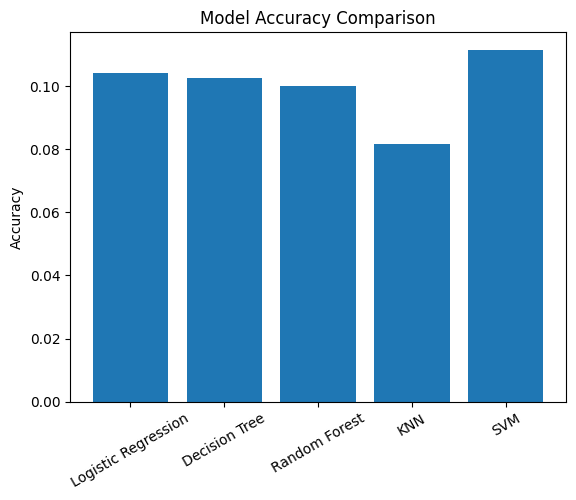

In [19]:
import matplotlib.pyplot as plt

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [20]:
import joblib

joblib.dump(best_model, "plant_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Best model saved!")

Best model saved!
